In [1]:
# Install required libraries
!pip install gradio kaggle -q

# Mount Google Drive (to save your model)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()
# A button will appear → click it → select kaggle.json from your Downloads folder

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdkhalidhasanmilu1","key":"3a78b5a58212c3521a9c7335fe85734c"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API ready!")

✅ Kaggle API ready!


In [4]:
!kaggle datasets list

ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                   Social Media Impact on Teen Mental Health               16190  2026-04-05 08:04:21.823000          26267        561                1  
sridipbasu/ai-depndency-career-anxiety-and-student-burnout       AI Depndency, Career Anxiety and Student Burnout       447453  2026-05-10 18:26:03.943000            559         25                1  
sharmajicoder/gen-z-social-media-usage-dataset                   Gen-Z Social Media Usage Dataset                     44185801  2026-04-25 08:23:33.093000           3727         76                1  


In [5]:
!kaggle datasets download -d emmarex/plantdisease
print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:06<00:00, 99.1MB/s]

✅ Download complete!


In [6]:
!unzip -q plantdisease.zip -d /content/plantdisease
print("✅ Unzip complete!")
!ls /content/plantdisease

✅ Unzip complete!
plantvillage  PlantVillage


In [7]:
import os

base_dir = '/content/plantdisease/PlantVillage'
all_classes = os.listdir(base_dir)
tomato_classes = sorted([c for c in all_classes if 'Tomato' in c])

print(f"✅ Found {len(tomato_classes)} tomato classes:\n")
for i, c in enumerate(tomato_classes):
    count = len(os.listdir(os.path.join(base_dir, c)))
    print(f"  {i+1}. {c}  →  {count} images")

✅ Found 10 tomato classes:

  1. Tomato_Bacterial_spot  →  2127 images
  2. Tomato_Early_blight  →  1000 images
  3. Tomato_Late_blight  →  1909 images
  4. Tomato_Leaf_Mold  →  952 images
  5. Tomato_Septoria_leaf_spot  →  1771 images
  6. Tomato_Spider_mites_Two_spotted_spider_mite  →  1676 images
  7. Tomato__Target_Spot  →  1404 images
  8. Tomato__Tomato_YellowLeaf__Curl_Virus  →  3209 images
  9. Tomato__Tomato_mosaic_virus  →  373 images
  10. Tomato_healthy  →  1591 images


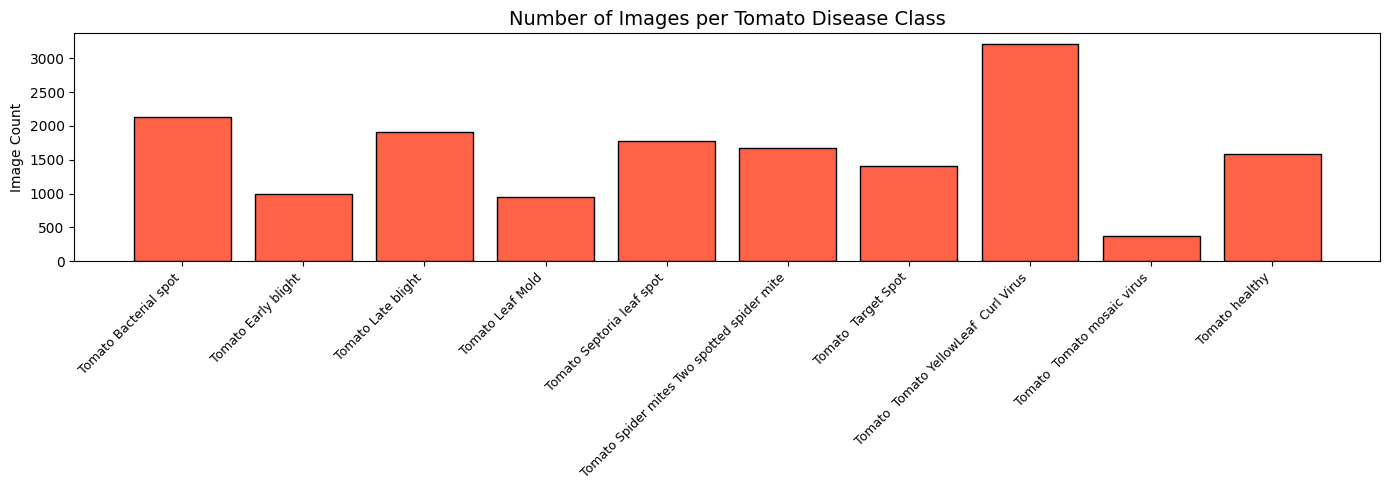

✅ Chart saved!


In [8]:
import matplotlib.pyplot as plt

base_dir = '/content/plantdisease/PlantVillage'
tomato_classes = sorted([c for c in os.listdir(base_dir) if 'Tomato' in c])

counts = [len(os.listdir(os.path.join(base_dir, c))) for c in tomato_classes]
short_names = [c.replace('Tomato___', '').replace('_', ' ') for c in tomato_classes]

plt.figure(figsize=(14, 5))
plt.bar(short_names, counts, color='tomato', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Number of Images per Tomato Disease Class', fontsize=14)
plt.ylabel('Image Count')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved!")

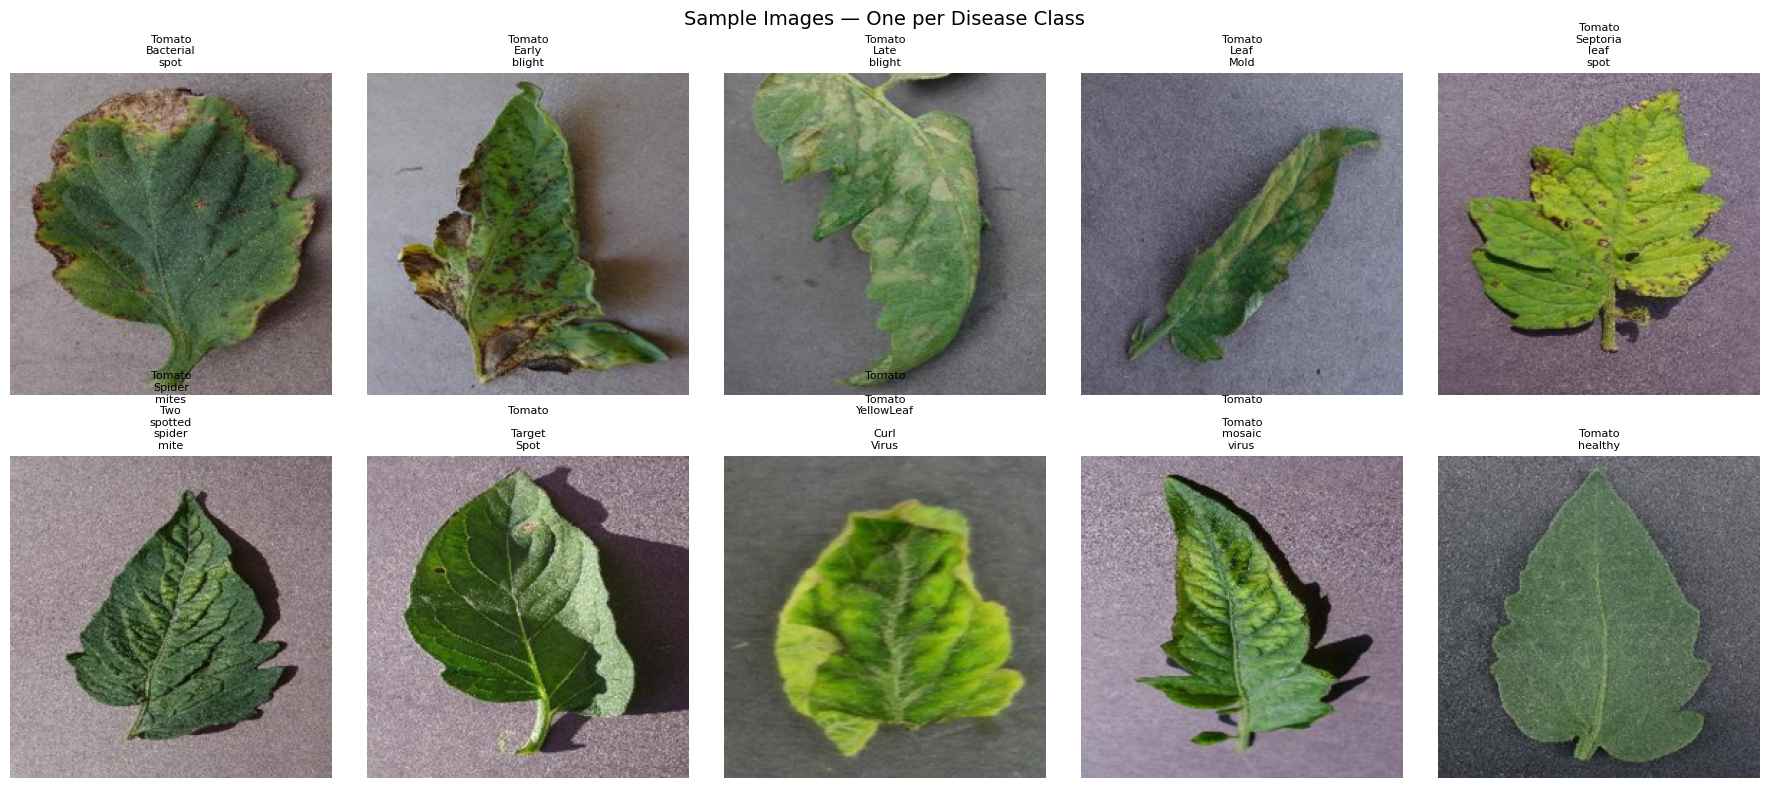

✅ Sample images saved!


In [9]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(tomato_classes):
    folder = os.path.join(base_dir, cls)
    img_file = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_file)).resize((224, 224))
    axes[i].imshow(img)
    axes[i].set_title(cls.replace('Tomato___', '').replace('_', '\n'), fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Images — One per Disease Class', fontsize=14)
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150)
plt.show()
print("✅ Sample images saved!")

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil, numpy as np

IMG_SIZE = 224
BATCH_SIZE = 32

# Copy only tomato folders to a new directory
tomato_dir = '/content/tomato_data'
os.makedirs(tomato_dir, exist_ok=True)

for cls in tomato_classes:
    src = os.path.join(base_dir, cls)
    dst = os.path.join(tomato_dir, cls)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print("✅ Tomato data folder ready!")

✅ Tomato data folder ready!


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    brightness_range=[0.7, 1.3],
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    tomato_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    tomato_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

class_names = list(train_gen.class_indices.keys())
short_class_names = [c.replace('Tomato___', '').replace('_', ' ') for c in class_names]
NUM_CLASSES = len(class_names)

print(f"✅ Ready! Total classes: {NUM_CLASSES}")
print(f"   Training batches: {len(train_gen)}")
print(f"   Validation batches: {len(val_gen)}")

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.
✅ Ready! Total classes: 10
   Training batches: 401
   Validation batches: 100


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model, Input

def build_mobilenetv2(num_classes):
    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Freeze base layers

    inputs = Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

mobile_model = build_mobilenetv2(NUM_CLASSES)
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built!")
mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    ModelCheckpoint('/content/best_mobilenet.h5', save_best_only=True, verbose=1)
]

print("🚀 Training started... (takes ~15-20 mins)")

history1 = mobile_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks
)
print("✅ Phase 1 training complete!")

🚀 Training started... (takes ~15-20 mins)
Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.4063 - loss: 1.7667
Epoch 1: val_loss improved from None to 0.89329, saving model to /content/best_mobilenet.h5



Epoch 1: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 235s 535ms/step - accuracy: 0.5483 - loss: 1.3599 - val_accuracy: 0.7145 - val_loss: 0.8933 - learning_rate: 1.0000e-04
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6973 - loss: 0.8994
Epoch 2: val_loss improved from 0.89329 to 0.71097, saving model to /content/best_mobilenet.h5



Epoch 2: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 187s 467ms/step - accuracy: 0.7178 - loss: 0.8458 - val_accuracy: 0.7664 - val_loss: 0.7110 - learning_rate: 1.0000e-04
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.7579 - loss: 0.7287
Epoch 3: val_loss improved from 0.71097 to 0.62114, saving model to /content/best_mobilenet.h5



Epoch 3: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 188s 469ms/step - accuracy: 0.7655 - loss: 0.7003 - val_accuracy: 0.7921 - val_loss: 0.6211 - learning_rate: 1.0000e-04
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7941 - loss: 0.6303
Epoch 4: val_loss improved from 0.62114 to 0.57388, saving model to /content/best_mobilenet.h5



Epoch 4: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 186s 464ms/step - accuracy: 0.7933 - loss: 0.6248 - val_accuracy: 0.8039 - val_loss: 0.5739 - learning_rate: 1.0000e-04
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.7972 - loss: 0.5915
Epoch 5: val_loss improved from 0.57388 to 0.52103, saving model to /content/best_mobilenet.h5


...


Epoch 10: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 187s 467ms/step - accuracy: 0.8501 - loss: 0.4495 - val_accuracy: 0.8502 - val_loss: 0.4346 - learning_rate: 1.0000e-04
Epoch 11/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8568 - loss: 0.4248
Epoch 11: val_loss did not improve from 0.43465
401/401 ━━━━━━━━━━━━━━━━━━━━ 185s 461ms/step - accuracy: 0.8561 - loss: 0.4233 - val_accuracy: 0.8499 - val_loss: 0.4442 - learning_rate: 1.0000e-04
Epoch 12/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8592 - loss: 0.4231
Epoch 12: val_loss improved from 0.43465 to 0.41362, saving model to /content/best_mobilenet.h5



Epoch 12: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 188s 468ms/step - accuracy: 0.8594 - loss: 0.4151 - val_accuracy: 0.8602 - val_loss: 0.4136 - learning_rate: 1.0000e-04
Epoch 13/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8551 - loss: 0.4299
Epoch 13: val_loss improved from 0.41362 to 0.40140, saving model to /content/best_mobilenet.h5



Epoch 13: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 183s 455ms/step - accuracy: 0.8612 - loss: 0.4093 - val_accuracy: 0.8583 - val_loss: 0.4014 - learning_rate: 1.0000e-04
Epoch 14/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8633 - loss: 0.3961
Epoch 14: val_loss improved from 0.40140 to 0.39768, saving model to /content/best_mobilenet.h5



Epoch 14: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 189s 472ms/step - accuracy: 0.8662 - loss: 0.3940 - val_accuracy: 0.8612 - val_loss: 0.3977 - learning_rate: 1.0000e-04
Epoch 15/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8692 - loss: 0.3865
Epoch 15: val_loss improved from 0.39768 to 0.38370, saving model to /content/best_mobilenet.h5



Epoch 15: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 188s 469ms/step - accuracy: 0.8675 - loss: 0.3852 - val_accuracy: 0.8659 - val_loss: 0.3837 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 15.
✅ Phase 1 training complete!


In [14]:
# Unfreeze last 30 layers of MobileNetV2
base_model = mobile_model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very small learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Fine-tuning started...")

history2 = mobile_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)
print("✅ Fine-tuning complete!")

🚀 Fine-tuning started...
Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.6664 - loss: 1.0629
Epoch 1: val_loss did not improve from 0.38370
401/401 ━━━━━━━━━━━━━━━━━━━━ 219s 503ms/step - accuracy: 0.7460 - loss: 0.7715 - val_accuracy: 0.8580 - val_loss: 0.4336 - learning_rate: 1.0000e-05
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8259 - loss: 0.4987
Epoch 2: val_loss did not improve from 0.38370
401/401 ━━━━━━━━━━━━━━━━━━━━ 183s 455ms/step - accuracy: 0.8297 - loss: 0.4912 - val_accuracy: 0.8743 - val_loss: 0.4003 - learning_rate: 1.0000e-05
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8564 - loss: 0.4335
Epoch 3: val_loss improved from 0.38370 to 0.37356, saving model to /content/best_mobilenet.h5



Epoch 3: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 183s 455ms/step - accuracy: 0.8596 - loss: 0.4191 - val_accuracy: 0.8752 - val_loss: 0.3736 - learning_rate: 1.0000e-05
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8726 - loss: 0.3743
Epoch 4: val_loss improved from 0.37356 to 0.35571, saving model to /content/best_mobilenet.h5



Epoch 4: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 181s 449ms/step - accuracy: 0.8705 - loss: 0.3785 - val_accuracy: 0.8859 - val_loss: 0.3557 - learning_rate: 1.0000e-05
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8819 - loss: 0.3440
Epoch 5: val_loss improved from 0.35571 to 0.34102, saving model to /content/best_mobilenet.h5



Epoch 5: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 181s 451ms/step - accuracy: 0.8817 - loss: 0.3469 - val_accuracy: 0.8906 - val_loss: 0.3410 - learning_rate: 1.0000e-05
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8924 - loss: 0.3112
Epoch 6: val_loss improved from 0.34102 to 0.31870, saving model to /content/best_mobilenet.h5



Epoch 6: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 184s 458ms/step - accuracy: 0.8928 - loss: 0.3127 - val_accuracy: 0.8940 - val_loss: 0.3187 - learning_rate: 1.0000e-05
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8922 - loss: 0.3188
Epoch 7: val_loss improved from 0.31870 to 0.29804, saving model to /content/best_mobilenet.h5



Epoch 7: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 185s 460ms/step - accuracy: 0.8943 - loss: 0.3099 - val_accuracy: 0.8968 - val_loss: 0.2980 - learning_rate: 1.0000e-05
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9056 - loss: 0.2666
Epoch 8: val_loss improved from 0.29804 to 0.29396, saving model to /content/best_mobilenet.h5



Epoch 8: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 184s 458ms/step - accuracy: 0.9043 - loss: 0.2722 - val_accuracy: 0.9003 - val_loss: 0.2940 - learning_rate: 1.0000e-05
Epoch 9/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9055 - loss: 0.2720
Epoch 9: val_loss did not improve from 0.29396
401/401 ━━━━━━━━━━━━━━━━━━━━ 182s 452ms/step - accuracy: 0.9092 - loss: 0.2662 - val_accuracy: 0.8987 - val_loss: 0.3062 - learning_rate: 1.0000e-05
Epoch 10/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9178 - loss: 0.2505
Epoch 10: val_loss improved from 0.29396 to 0.27196, saving model to /content/best_mobilenet.h5



Epoch 10: finished saving model to /content/best_mobilenet.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 186s 464ms/step - accuracy: 0.9175 - loss: 0.2485 - val_accuracy: 0.9096 - val_loss: 0.2720 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.
✅ Fine-tuning complete!


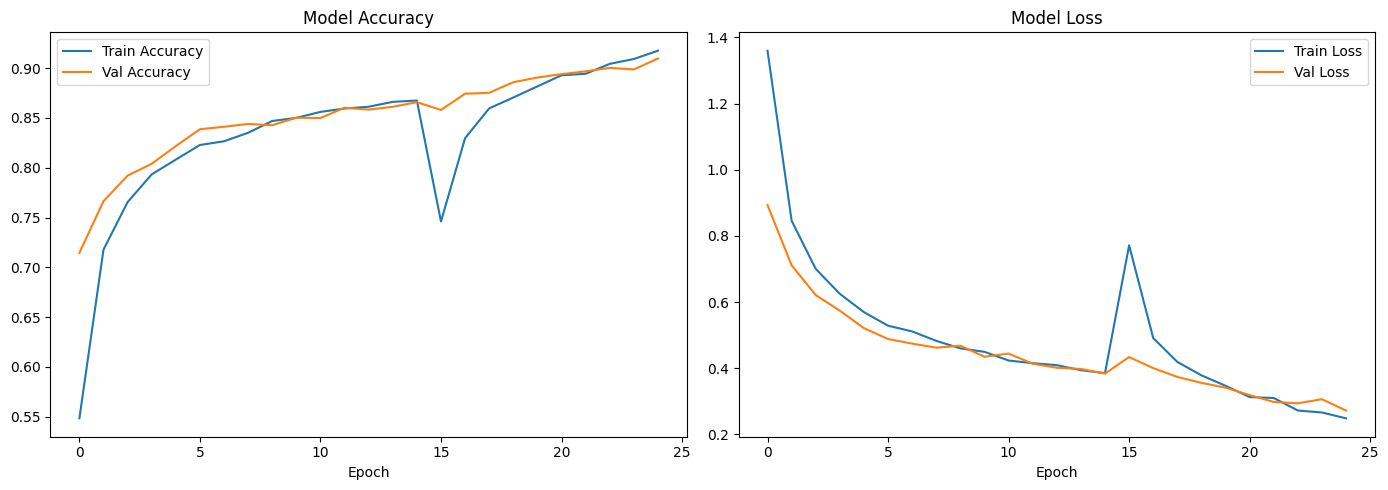

✅ Training curves saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine both histories
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved!")

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get predictions
val_gen.reset()
print("🔄 Getting predictions...")
y_pred_probs = mobile_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# Print classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=short_class_names))

🔄 Getting predictions...
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step

📊 Classification Report:

                                             precision    recall  f1-score   support

                      Tomato Bacterial spot       0.15      0.16      0.15       425
                        Tomato Early blight       0.05      0.03      0.04       200
                         Tomato Late blight       0.11      0.10      0.10       381
                           Tomato Leaf Mold       0.08      0.08      0.08       190
                  Tomato Septoria leaf spot       0.10      0.11      0.11       354
Tomato Spider mites Two spotted spider mite       0.12      0.09      0.10       335
                        Tomato  Target Spot       0.07      0.10      0.08       280
      Tomato  Tomato YellowLeaf  Curl Virus       0.19      0.19      0.19       641
                Tomato  Tomato mosaic virus       0.01      0.01      0.01        74
                             Tomato healthy       0.1

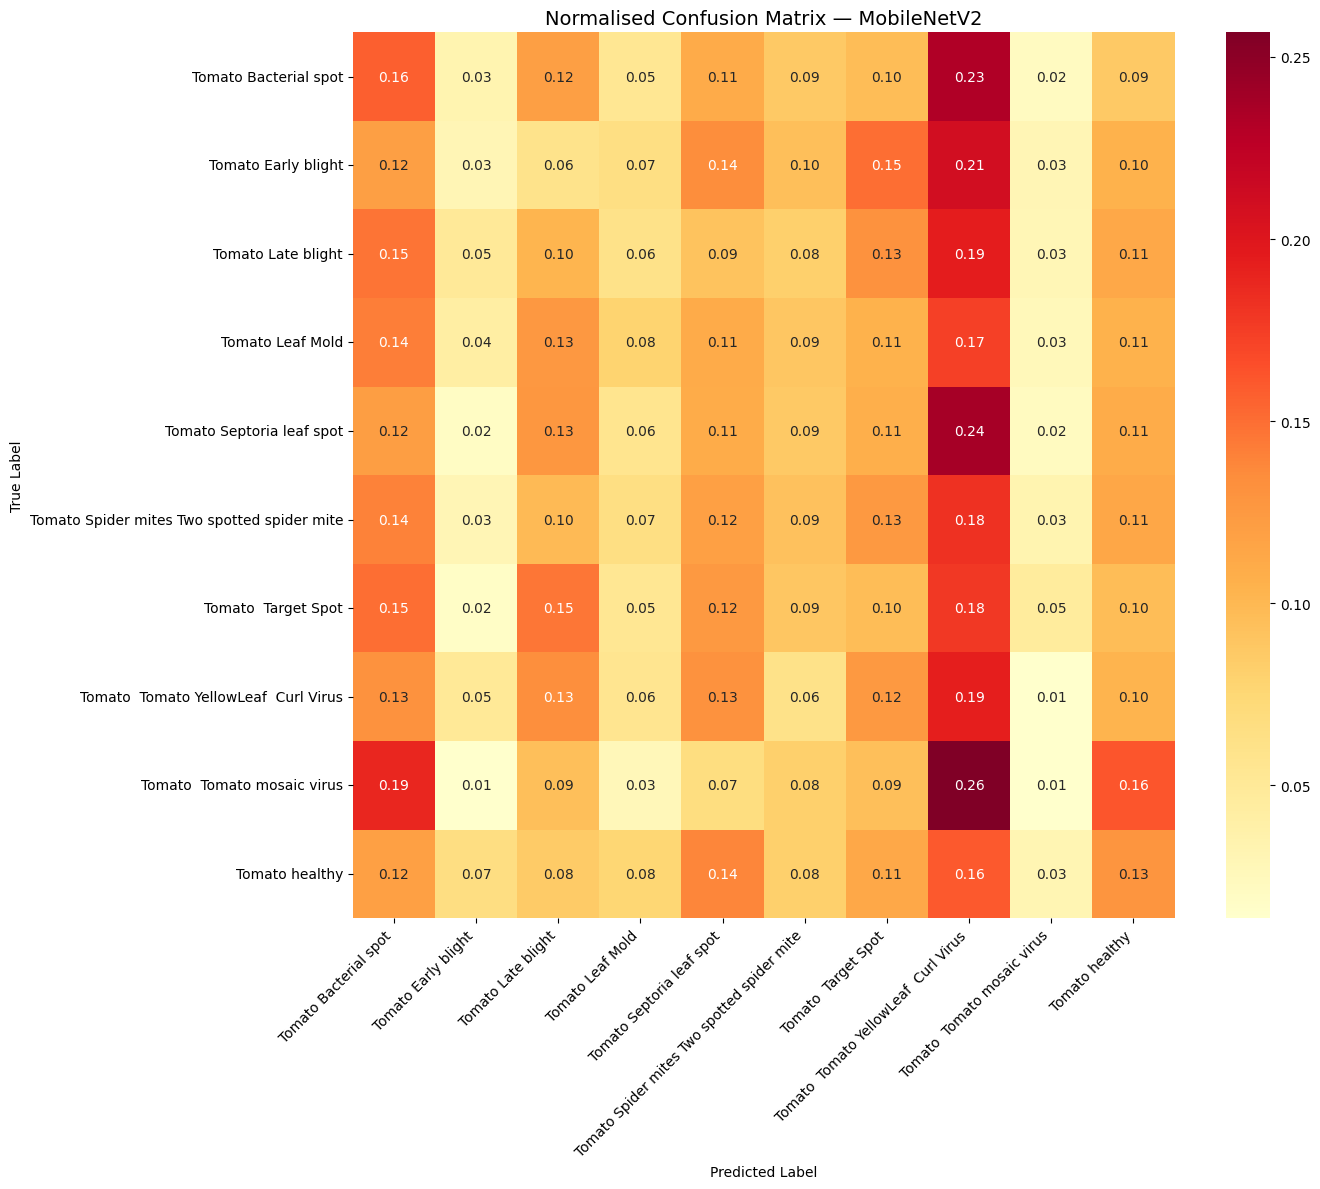

✅ Confusion matrix saved!


In [17]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='.2f',
    xticklabels=short_class_names,
    yticklabels=short_class_names,
    cmap='YlOrRd'
)
plt.title('Normalised Confusion Matrix — MobileNetV2', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [18]:
mobile_model.save('/content/tomato_disease_model.h5')
print("✅ Model saved!")

✅ Model saved!


In [19]:
!pip install gradio -q
import gradio as gr

# Treatment advice for each disease
TREATMENTS = {
    'Bacterial Spot': '🌿 Remove infected leaves. Apply copper-based bactericide. Avoid overhead watering.',
    'Early Blight': '🍂 Apply fungicide (chlorothalonil). Remove lower infected leaves. Rotate crops.',
    'Late Blight': '⚠️ Apply fungicide immediately (mancozeb). Destroy infected plants. Ensure good drainage.',
    'Leaf Mold': '💧 Improve air circulation. Reduce humidity. Apply fungicide.',
    'Septoria Leaf Spot': '🔬 Remove infected leaves. Apply fungicide. Avoid wetting foliage.',
    'Spider Mites Two Spotted Spider Mite': '🕷️ Apply miticide or neem oil. Spray water on leaves.',
    'Target Spot': '🎯 Apply fungicide. Remove infected debris. Avoid overcrowding.',
    'Tomato Yellow Leaf Curl Virus': '🦟 Control whitefly population. Remove infected plants. Use resistant varieties.',
    'Tomato Mosaic Virus': '🚫 No cure — remove infected plants. Disinfect tools. Plant resistant varieties.',
    'Healthy': '✅ Your tomato plant looks healthy! Keep up good farming practices.'
}

def predict_disease(image):
    # Preprocess image
    img = tf.image.resize(image, [224, 224])
    img = tf.expand_dims(img / 255.0, axis=0)

    # Predict
    preds = mobile_model.predict(img)[0]
    top3_idx = np.argsort(preds)[::-1][:3]

    top_class = short_class_names[top3_idx[0]]
    top_conf = preds[top3_idx[0]] * 100
    treatment = TREATMENTS.get(top_class, 'Consult an agricultural expert.')

    # Top 3 predictions
    conf_text = "\n".join([
        f"  {i+1}. {short_class_names[idx]}: {preds[idx]*100:.1f}%"
        for i, idx in enumerate(top3_idx)
    ])

    result = f"""
🔍 DIAGNOSIS RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━
🍅 Disease     : {top_class}
📊 Confidence  : {top_conf:.1f}%

📋 TOP 3 PREDICTIONS:
{conf_text}

💊 TREATMENT ADVICE:
{treatment}

━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  Disclaimer: This AI tool is for guidance
    only. Consult an agricultural expert
    for severe cases.
"""
    return result

# Launch GUI
interface = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="numpy", label="📸 Upload Tomato Leaf Photo"),
    outputs=gr.Textbox(label="🩺 Diagnosis & Treatment", lines=20),
    title="🍅 Tomato Leaf Disease Classifier",
    description="Upload a photo of a tomato leaf. The AI will identify the disease and suggest treatment.",
    theme="soft"
)

interface.launch(share=True, debug=True)
print("✅ GUI is running!")

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://29a111f1556c821212.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://29a111f1556c821212.gradio.live
✅ GUI is running!


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Save model
shutil.copy('/content/tomato_disease_model.h5',
            '/content/drive/MyDrive/tomato_disease_model.h5')

# Save all charts
for f in ['class_distribution.png', 'sample_images.png',
          'training_curves.png', 'confusion_matrix.png']:
    shutil.copy(f'/content/{f}', f'/content/drive/MyDrive/{f}')

print("✅ Everything saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Everything saved to Google Drive!


In [21]:
# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/tomato_disease_model.h5', '/content/drive/MyDrive/tomato_disease_model.h5')

for f in ['class_distribution.png', 'sample_images.png', 'training_curves.png', 'confusion_matrix.png']:
    shutil.copy(f'/content/{f}', f'/content/drive/MyDrive/{f}')

print("✅ All saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All saved to Google Drive!
